In [1]:
# make sure to choose the python_course environment+activate conda

# import libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

#load dataset
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# data cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

c:\Users\stuco\anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import seaborn as sns

In [3]:
# filter for US Data Analyst jobs
df_DA_US = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()

#remove NaN values so plotting is accurate
df_DA_US = df_DA_US.dropna(subset=['salary_year_avg'])

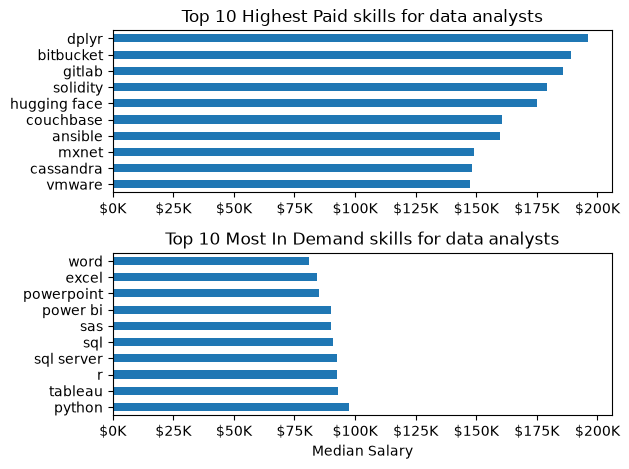

In [6]:
# copy over the steps used to make the charts in the last lesson

df_DA_US = df_DA_US.explode('job_skills')

df_DA_top_pay = df_DA_US.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='median', ascending=False)
df_DA_top_pay = df_DA_top_pay.head(10)

df_DA_skills = df_DA_US.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='count', ascending=False)
df_DA_skills = df_DA_skills.head(10).sort_values(by='median', ascending=False)

fig, ax = plt.subplots(2, 1)

df_DA_top_pay[::-1].plot(kind="barh", y='median', ax=ax[0], legend=False)
ax[0].set_title("Top 10 Highest Paid skills for data analysts")
ax[0].set_ylabel('')
ax[0].set_xlabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

df_DA_skills.plot(kind="barh", y='median', ax=ax[1], legend=False)
ax[1].set_title("Top 10 Most In Demand skills for data analysts")
ax[1].set_ylabel('')
ax[1].set_xlabel('Median Salary')
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

ax[1].set_xlim(ax[0].get_xlim()) # this line calls the xlim from top_pay and applies it to DA_skills for better comparison

fig.tight_layout()
plt.show()



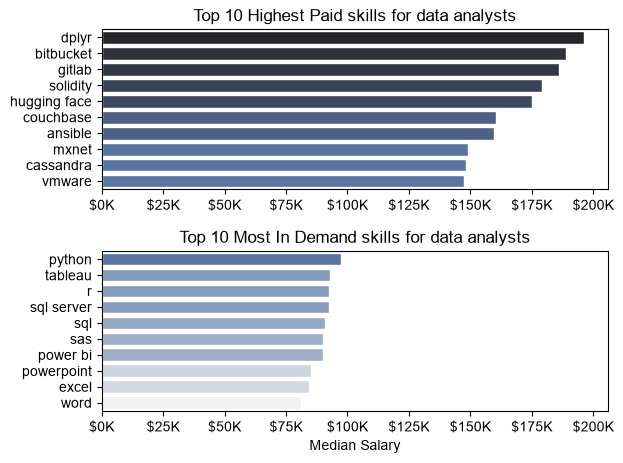

In [ ]:
# here we'll use seaborn, we keep most of the code but get rid of anywhere we use the plot method
# seaborn boxplot is similar to matplotlib but can also specify hue for color gradient'
# going to use gradient to showcase differences in salary. Darker=Higher, lighter=Less

fig, ax = plt.subplots(2, 1)

sns.set_theme(style="ticks") # puts tick marks on the x axis

sns.barplot(data=df_DA_top_pay, x='median', y=df_DA_top_pay.index, ax=ax[0], hue='median', palette='dark:b_r') # _r reverses the color gradient
ax[0].legend().remove()

#df_DA_top_pay[::-1].plot(kind="barh", y='median', ax=ax[0], legend=False)
ax[0].set_title("Top 10 Highest Paid skills for data analysts")
ax[0].set_ylabel('')
ax[0].set_xlabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

sns.barplot(data=df_DA_skills, x='median', y=df_DA_skills.index, ax=ax[1], hue='median', palette="light:b")
ax[1].legend().remove()

#df_DA_skills.plot(kind="barh", y='median', ax=ax[1], legend=False)
ax[1].set_title("Top 10 Most In Demand skills for data analysts")
ax[1].set_ylabel('')
ax[1].set_xlabel('Median Salary')
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

ax[1].set_xlim(ax[0].get_xlim()) # this line calls the xlim from top_pay and applies it to DA_skills for better comparison

fig.tight_layout()
plt.show()
